In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


from sklearn.metrics import make_scorer, confusion_matrix

In [40]:
data = pd.read_csv('Final_data1.csv')
data = data.rename(columns={'Freezing of gait in past 12 months': 'Freezing of gait in past 36 months', 'Falls not rel to freezing past 12 months':'Falls not rel to freezing past 36 months'})
col = 'Falls not rel to freezing past 36 months'
data.loc[data[col] > 2, col] = 2
data['BMI'] = data['BMI'].apply(lambda x: 25.05736 if x > 123 else x)
data1 = data[data['BMI'] <= 50]

#No BMI values
data1=data1[data1['BMI']>0]

In [41]:
updrs1 = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Motor___MDS-UPDRS/MDS-UPDRS_Part_I_26Jan2026.csv')
latest_rows_updrs1 = (
    updrs1.groupby('PATNO', as_index=False)['NP1RTOT']
    .max()
)
updrs1_latest = latest_rows_updrs1[['PATNO', 'NP1RTOT']].reset_index(drop=True)
data2 = data1.merge(updrs1_latest, on='PATNO', how='left')
data2.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 36 months,Falls not rel to freezing past 36 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years,NP1RTOT
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,15,10.0
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,16,5.0
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,14,13.0
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,14,6.0
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,13,8.0


In [42]:


# Convert "MM/YYYY" to a proper date (set day=1)
data2['BIRTHDT'] = pd.to_datetime(data2['BIRTHDT'], format='%m/%Y')

today = pd.to_datetime('today')

# Compute age manually
data2['Age'] = (today.year - data2['BIRTHDT'].dt.year) - \
              ((today.month < data2['BIRTHDT'].dt.month).astype(int))

#not including 'Fall related consequences' in the training data
cols = ['No_of_years','Age',
       'Postural instability present at dx?','Rigidity present at diagnosis?',
       'Dopaminergic therapy started for participant', 'MoCA Total Score',
       'Freezing of gait in past 36 months',
       'lightheaded after standing', 'fainted',
       'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min', 'Total Depression Score',
       'MDS-UPDRS PartIV score','BMI','NP1RTOT'
]

X = data2[cols]
Y = data2['Falls not rel to freezing past 36 months']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42, stratify=Y)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Stage-1 Best Params: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Stage-1 best params (LinearSVC): {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Stage-2 Best Params: {'clf__C': 0.01}

=== Two-Stage Classification Report (3-class) ===
              precision    recall  f1-score   support

         0.0     0.7887    0.7018    0.7427       218
         1.0     0.3796    0.4271    0.4020        96
         2.0     0.5400    0.7105    0.6136        38

    accuracy                         0.6278       352
   macro avg     0.5694    0.6131    0.5861       352
weighted avg     0.6503    0.6278    0.6358       352


=== Stage-1 Report (0 vs {1,2}) ===
              precision    reca

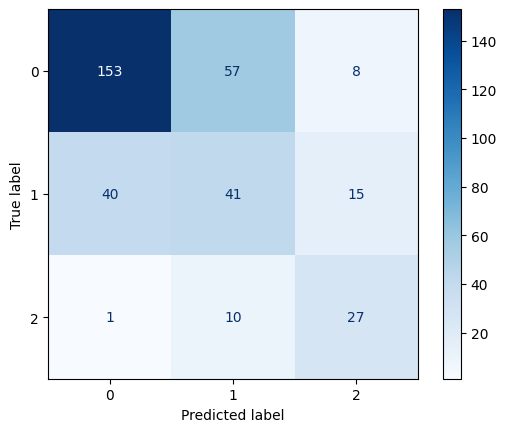

In [6]:
import numpy as np
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import make_scorer, confusion_matrix

rf_stage1 = RandomForestClassifier(class_weight={0: 1, 1: 2}, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5]
}

cv1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# gs_stage1 = GridSearchCV(
#     estimator=rf_stage1,
#     param_grid=param_grid,
#     cv=cv1,
#     scoring="f1",          # binary f1 for stage-1
#     n_jobs=-1,
#     verbose=1
# )
from sklearn.metrics import make_scorer, confusion_matrix

def cost_score(y_true, y_pred, fn_cost=5, fp_cost=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    cost = fn_cost*fn + fp_cost*fp
    return -cost  # GridSearchCV maximizes

stage1_cost_scorer = make_scorer(cost_score, greater_is_better=True, fn_cost=6, fp_cost=1)

gs_stage1 = GridSearchCV(
    rf_stage1,
    param_grid=param_grid,
    cv=cv1,
    scoring=stage1_cost_scorer,
    n_jobs=-1,
    verbose=1
)
y_train_s1 = (y_train != 0).astype(int)  # 0 -> 0, 1/2 -> 1
y_test_s1  = (y_test  != 0).astype(int)

# Fit stage-1
gs_stage1.fit(X_train, y_train_s1)
best_stage1 = gs_stage1.best_estimator_
print("Stage-1 Best Params:", gs_stage1.best_params_)
gs_stage1.fit(X_train, y_train_s1)
best_stage1 = gs_stage1.best_estimator_
print("Stage-1 best params (LinearSVC):", gs_stage1.best_params_)

svm_pipe1 = Pipeline([
    ("scaler", StandardScaler(with_mean=False) if hasattr(X_train, "sparse") else StandardScaler()),
    ("clf", LinearSVC(class_weight="balanced", random_state=42,dual=False))
])

param_grid_svm = {
    "clf__C": [0.01, 0.1, 1, 10]
}

gs_stage2 = GridSearchCV(
    svm_pipe1, param_grid_svm,
    cv=cv1,
    n_jobs=-1,
    verbose=1
)


# ---------------------------------------------------
# 3) Stage-2 training set: only samples with {1,2}
# ---------------------------------------------------
import pandas as pd

# Convert y to pandas Series with same index as X
y_train = pd.Series(y_train, index=X_train.index)
y_test  = pd.Series(y_test,  index=X_test.index)

# Now this works safely
mask_train_12 = y_train != 0
X_train_12 = X_train.loc[mask_train_12]
y_train_12 = y_train.loc[mask_train_12]
 

# Map {1,2} -> {0,1} for stage-2
y_train_s2 = (y_train_12 == 2).astype(int)  # 1 -> 0, 2 -> 1

# Fit stage-2
gs_stage2.fit(X_train_12, y_train_s2)
best_stage2 = gs_stage2.best_estimator_
print("Stage-2 Best Params:", gs_stage2.best_params_)

# ---------------------------------------
# 4) Two-stage inference on the test set
# ---------------------------------------
# Stage-1 prediction: 0 vs (1/2)
pred_s1 = best_stage1.predict(X_test)  # 0 or 1

# Initialize final preds as 0
y_pred_two_stage = np.zeros_like(y_test)

# For samples predicted as (1/2), run stage-2
idx_12 = np.where(pred_s1 == 1)[0]
if len(idx_12) > 0:
    pred_s2 = best_stage2.predict(X_test.iloc[idx_12])  # 0->class1, 1->class2
    y_pred_two_stage[idx_12] = np.where(pred_s2 == 0, 1, 2)

# -------------------------
# 5) Evaluation (3-class)
# -------------------------
print("\n=== Two-Stage Classification Report (3-class) ===")
print(classification_report(y_test, y_pred_two_stage, digits=4))

cm = confusion_matrix(y_test, y_pred_two_stage, labels=[0,1,2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2])
disp.plot(cmap="Blues")

# -------------------------
# 6) Optional: Stage-wise reports
# -------------------------
print("\n=== Stage-1 Report (0 vs {1,2}) ===")
print(classification_report(y_test_s1, pred_s1, digits=4))

# Evaluate stage-2 only where true label is in {1,2}
# 
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# mask of samples routed to stage-2 (stage-1 predicted {1,2})
mask_routed = (pred_s1 == 1)

# Subset X and y for only routed samples
X_routed = X_test.loc[mask_routed]
y_routed_true = y_test.loc[mask_routed]   # ground truth on routed samples

print("Routed samples count:", len(X_routed))
print("Routed true label distribution:\n", y_routed_true.value_counts().sort_index())

# Stage-2 predictions on routed samples
pred_s2_routed = best_stage2.predict(X_routed)  # 0/1 (meaning class1/class2)

# For stage-2 metrics, keep ONLY cases where ground truth is 1 or 2
mask_true_12 = y_routed_true.isin([1, 2])
y_true_12 = y_routed_true.loc[mask_true_12]

# Map y_true {1,2} -> {0,1} to match stage-2 outputs
y_true_s2 = (y_true_12 == 2).astype(int)

pred_s2_eval = pred_s2_routed[mask_true_12.to_numpy()]  # align with filtered y_true_12

print("\n=== Stage-2 Report (pipeline-routed subset, true in {1,2}) ===")
print(classification_report(y_true_s2, pred_s2_eval, digits=4))
print("Confusion matrix (rows=true [1,2]=>[0,1], cols=pred [0,1]):")
print(confusion_matrix(y_true_s2, pred_s2_eval))




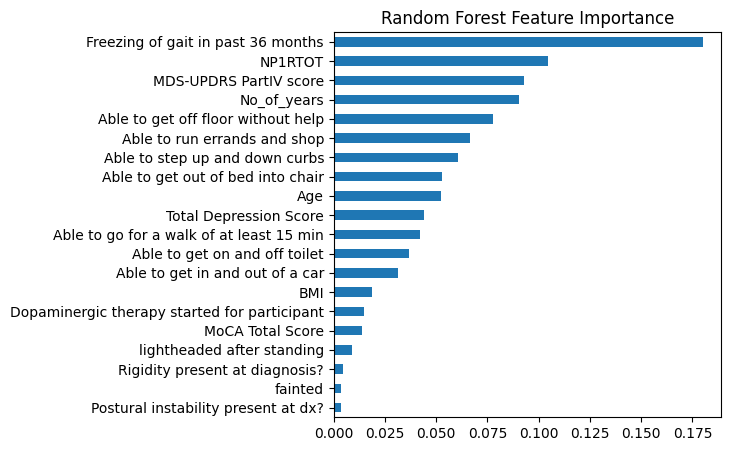

In [7]:
import matplotlib.pyplot as plt

rf_importances = pd.Series(best_stage1.feature_importances_, index=X_train.columns).sort_values(ascending=True)
rf_importances.plot(kind='barh', figsize=(5,5))
plt.title('Random Forest Feature Importance')
plt.show()


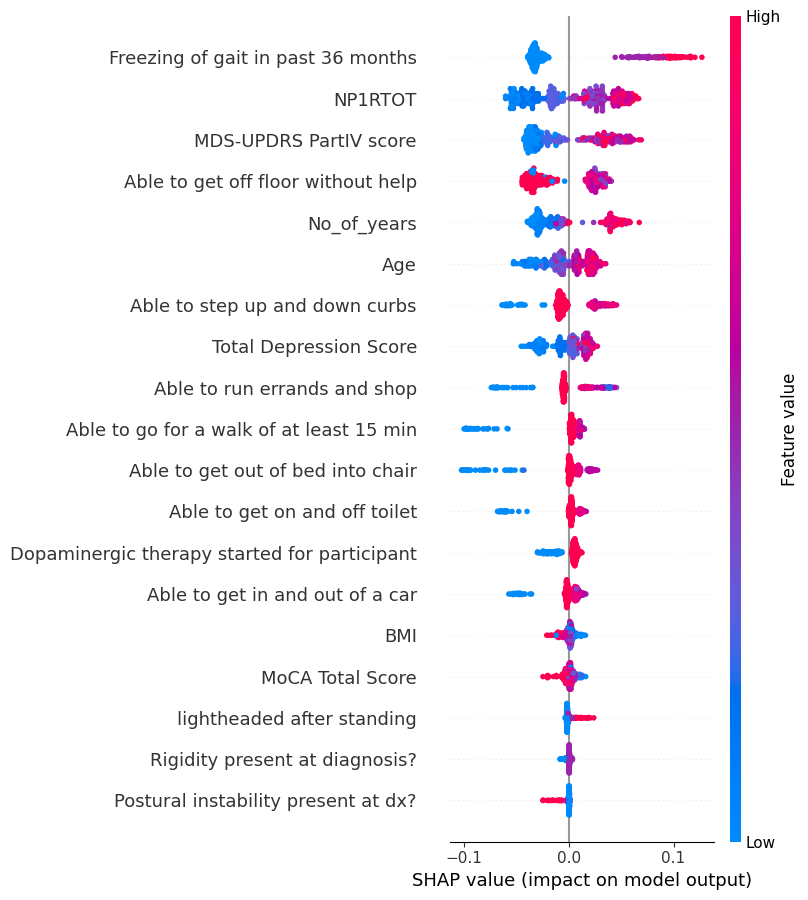

In [8]:
# Compute SHAP values
import shap
explainer = shap.Explainer(best_stage1, X_train)
shap_values = explainer(X_test)
# Select SHAP values for class 1 (any-fall)
shap_vals_stage1 = shap_values.values[:, :, 1]

# Beeswarm plot (all 19 features)
shap.summary_plot(
    shap_vals_stage1,
    X_test,
    plot_type="dot",     # beeswarm
    max_display=19
)

Add columns Daytime sleepiness, Urinary Problems

In [44]:
updrs1_ques = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Motor___MDS-UPDRS/MDS-UPDRS_Part_I_Patient_Questionnaire_26Jan2026.csv')
updrs1_ques['INFODT_parsed'] = pd.to_datetime(updrs1_ques['INFODT'], format='%m/%Y', errors='coerce')

updrs1_ques_sorted = updrs1_ques.sort_values(['PATNO', 'INFODT_parsed'])

def latest_non_nan(series):
    valid = series.dropna()
    return valid.iloc[-1] if len(valid) > 0 else np.nan

updrs1_ques_latest = (
    updrs1_ques_sorted.groupby('PATNO', as_index=False)
    .agg(
        NP1SLPD=('NP1SLPD', latest_non_nan),
        NP1URIN=('NP1URIN', latest_non_nan)
    )
)
data3 = data1.merge(updrs1_ques_latest, on='PATNO', how='left')
data3.head()


,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 36 months,Falls not rel to freezing past 36 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years,NP1SLPD,NP1URIN
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,15,2.0,4.0
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,16,2.0,0.0
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,14,2.0,2.0
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,14,1.0,2.0
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,13,2.0,3.0


Adding Gait feature

In [45]:
gait = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/MDS-UPDRS_Part_III_26Jan2026.csv')
gait['INFODT_parsed'] = pd.to_datetime(gait['INFODT'], format='%m/%Y', errors='coerce')

gait_sorted = gait.sort_values(['PATNO', 'INFODT_parsed'])

def latest_non_nan(series):
    valid = series.dropna()
    return valid.iloc[-1] if len(valid) > 0 else np.nan

gait_latest = (
    gait_sorted.groupby('PATNO', as_index=False)
    .agg(
        NP3GAIT=('NP3GAIT', latest_non_nan),
        NP3PSTBL=('NP3PSTBL', latest_non_nan),
        NHY=('NHY', latest_non_nan)
    )
)
data4 = data3.merge(gait_latest, on='PATNO', how='left')
data4.head()

/var/folders/y4/fkn560k16c3__twnyy0m4jxr0000gn/T/ipykernel_75944/4011226657.py:1: DtypeWarning: Columns (0: DBSOFFTM, 1: DBSONTM) have mixed types. Specify dtype option on import or set low_memory=False.
  gait = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/MDS-UPDRS_Part_III_26Jan2026.csv')


,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 36 months,Falls not rel to freezing past 36 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years,NP1SLPD,NP1URIN,NP3GAIT,NP3PSTBL,NHY
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,15,2.0,4.0,1.0,1.0,2.0
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,16,2.0,0.0,1.0,0.0,2.0
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,14,2.0,2.0,1.0,1.0,3.0
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,14,1.0,2.0,1.0,0.0,2.0
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,13,2.0,3.0,101.0,101.0,5.0


In [ ]:
#Add Postural hypotension

In [47]:
postht = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Other_Clinical_Features_25Feb2026.csv')
postht['INFODT_parsed'] = pd.to_datetime(postht['INFODT'], format='%m/%Y', errors='coerce')

postht_sorted = postht.sort_values(['PATNO', 'INFODT_parsed'])

postht_latest = (
    postht_sorted.groupby('PATNO', as_index=False)
    .agg(
        FEATPOSHYP=('FEATPOSHYP', latest_non_nan)
    )
)
data5 = data4.merge(postht_latest, on='PATNO', how='left')
data5.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 36 months,Falls not rel to freezing past 36 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years,NP1SLPD,NP1URIN,NP3GAIT,NP3PSTBL,NHY,FEATPOSHYP
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,15,2.0,4.0,1.0,1.0,2.0,1.0
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,16,2.0,0.0,1.0,0.0,2.0,0.0
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,14,2.0,2.0,1.0,1.0,3.0,0.0
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,14,1.0,2.0,1.0,0.0,2.0,0.0
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,13,2.0,3.0,101.0,101.0,5.0,2.0


In [49]:
cols = ['No_of_years','Age',
       'Postural instability present at dx?','Rigidity present at diagnosis?',
       'Dopaminergic therapy started for participant', 'MoCA Total Score',
       'Freezing of gait in past 36 months',
       'lightheaded after standing', 'fainted',
       'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min', 'Total Depression Score',
       'MDS-UPDRS PartIV score','BMI','NHY','NP3PSTBL','FEATPOSHYP',
       'NP1SLPD','NP1URIN','NP3GAIT'
]
# Compute age manually
# Convert "MM/YYYY" to a proper date (set day=1)
data5['BIRTHDT'] = pd.to_datetime(data5['BIRTHDT'], format='%m/%Y')
data5['Age'] = (today.year - data5['BIRTHDT'].dt.year) - \
              ((today.month < data5['BIRTHDT'].dt.month).astype(int))
X = data5[cols]
Y = data5['Falls not rel to freezing past 36 months']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42, stratify=Y)

In [51]:
import numpy as np
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import make_scorer, confusion_matrix

rf_stage1 = RandomForestClassifier(class_weight={0: 1, 1: 2}, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5]
}

cv1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# gs_stage1 = GridSearchCV(
#     estimator=rf_stage1,
#     param_grid=param_grid,
#     cv=cv1,
#     scoring="f1",          # binary f1 for stage-1
#     n_jobs=-1,
#     verbose=1
# )
from sklearn.metrics import make_scorer, confusion_matrix

def cost_score(y_true, y_pred, fn_cost=5, fp_cost=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    cost = fn_cost*fn + fp_cost*fp
    return -cost  # GridSearchCV maximizes

stage1_cost_scorer = make_scorer(cost_score, greater_is_better=True, fn_cost=6, fp_cost=1)

gs_stage1 = GridSearchCV(
    rf_stage1,
    param_grid=param_grid,
    cv=cv1,
    scoring=stage1_cost_scorer,
    n_jobs=-1,
    verbose=1
)
y_train_s1 = (y_train != 0).astype(int)  # 0 -> 0, 1/2 -> 1
y_test_s1  = (y_test  != 0).astype(int)

# Fit stage-1
gs_stage1.fit(X_train, y_train_s1)
best_stage1 = gs_stage1.best_estimator_
print("Stage-1 Best Params:", gs_stage1.best_params_)
gs_stage1.fit(X_train, y_train_s1)
best_stage1 = gs_stage1.best_estimator_
print("Stage-1 best params (LinearSVC):", gs_stage1.best_params_)

svm_pipe1 = Pipeline([
    ("scaler", StandardScaler(with_mean=False) if hasattr(X_train, "sparse") else StandardScaler()),
    ("clf", LinearSVC(class_weight="balanced", random_state=42,dual=False))
])

param_grid_svm = {
    "clf__C": [0.01, 0.1, 1, 10]
}

gs_stage2 = GridSearchCV(
    svm_pipe1, param_grid_svm,
    cv=cv1,
    n_jobs=-1,
    verbose=1
)


# ---------------------------------------------------
# 3) Stage-2 training set: only samples with {1,2}
# ---------------------------------------------------
import pandas as pd

# Convert y to pandas Series with same index as X
y_train = pd.Series(y_train, index=X_train.index)
y_test  = pd.Series(y_test,  index=X_test.index)

# Now this works safely
mask_train_12 = y_train != 0
X_train_12 = X_train.loc[mask_train_12]
y_train_12 = y_train.loc[mask_train_12]
 

# Map {1,2} -> {0,1} for stage-2
y_train_s2 = (y_train_12 == 2).astype(int)  # 1 -> 0, 2 -> 1

# Fit stage-2
gs_stage2.fit(X_train_12, y_train_s2)
best_stage2 = gs_stage2.best_estimator_
print("Stage-2 Best Params:", gs_stage2.best_params_)

# ---------------------------------------
# 4) Two-stage inference on the test set
# ---------------------------------------
# Stage-1 prediction: 0 vs (1/2)
pred_s1 = best_stage1.predict(X_test)  # 0 or 1

# Initialize final preds as 0
y_pred_two_stage = np.zeros_like(y_test)

# For samples predicted as (1/2), run stage-2
idx_12 = np.where(pred_s1 == 1)[0]
if len(idx_12) > 0:
    pred_s2 = best_stage2.predict(X_test.iloc[idx_12])  # 0->class1, 1->class2
    y_pred_two_stage[idx_12] = np.where(pred_s2 == 0, 1, 2)

# -------------------------
# 5) Evaluation (3-class)
# -------------------------
print("\n=== Two-Stage Classification Report (3-class) ===")
print(classification_report(y_test, y_pred_two_stage, digits=4))

cm = confusion_matrix(y_test, y_pred_two_stage, labels=[0,1,2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2])
disp.plot(cmap="Blues")

# -------------------------
# 6) Optional: Stage-wise reports
# -------------------------
print("\n=== Stage-1 Report (0 vs {1,2}) ===")
print(classification_report(y_test_s1, pred_s1, digits=4))

# Evaluate stage-2 only where true label is in {1,2}
# 
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# mask of samples routed to stage-2 (stage-1 predicted {1,2})
mask_routed = (pred_s1 == 1)

# Subset X and y for only routed samples
X_routed = X_test.loc[mask_routed]
y_routed_true = y_test.loc[mask_routed]   # ground truth on routed samples

print("Routed samples count:", len(X_routed))
print("Routed true label distribution:\n", y_routed_true.value_counts().sort_index())

# Stage-2 predictions on routed samples
pred_s2_routed = best_stage2.predict(X_routed)  # 0/1 (meaning class1/class2)

# For stage-2 metrics, keep ONLY cases where ground truth is 1 or 2
mask_true_12 = y_routed_true.isin([1, 2])
y_true_12 = y_routed_true.loc[mask_true_12]

# Map y_true {1,2} -> {0,1} to match stage-2 outputs
y_true_s2 = (y_true_12 == 2).astype(int)

pred_s2_eval = pred_s2_routed[mask_true_12.to_numpy()]  # align with filtered y_true_12

print("\n=== Stage-2 Report (pipeline-routed subset, true in {1,2}) ===")
print(classification_report(y_true_s2, pred_s2_eval, digits=4))
print("Confusion matrix (rows=true [1,2]=>[0,1], cols=pred [0,1]):")
print(confusion_matrix(y_true_s2, pred_s2_eval))




Fitting 5 folds for each of 540 candidates, totalling 2700 fits


KeyboardInterrupt: 

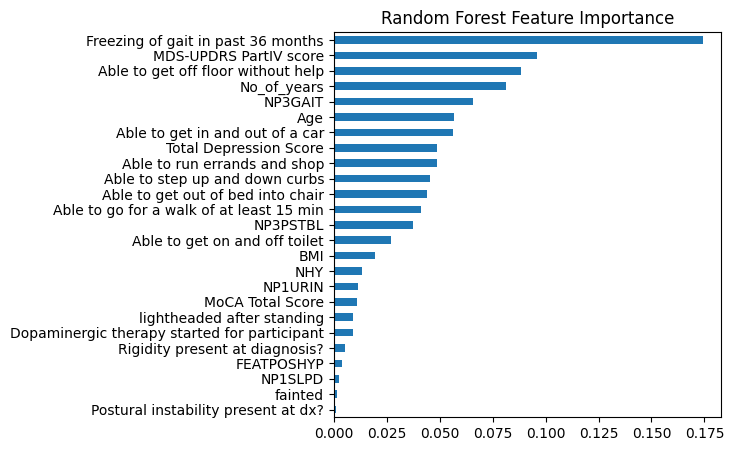

In [35]:
import matplotlib.pyplot as plt

rf_importances = pd.Series(best_stage1.feature_importances_, index=X_train.columns).sort_values(ascending=True)
rf_importances.plot(kind='barh', figsize=(5,5))
plt.title('Random Forest Feature Importance')
plt.show()


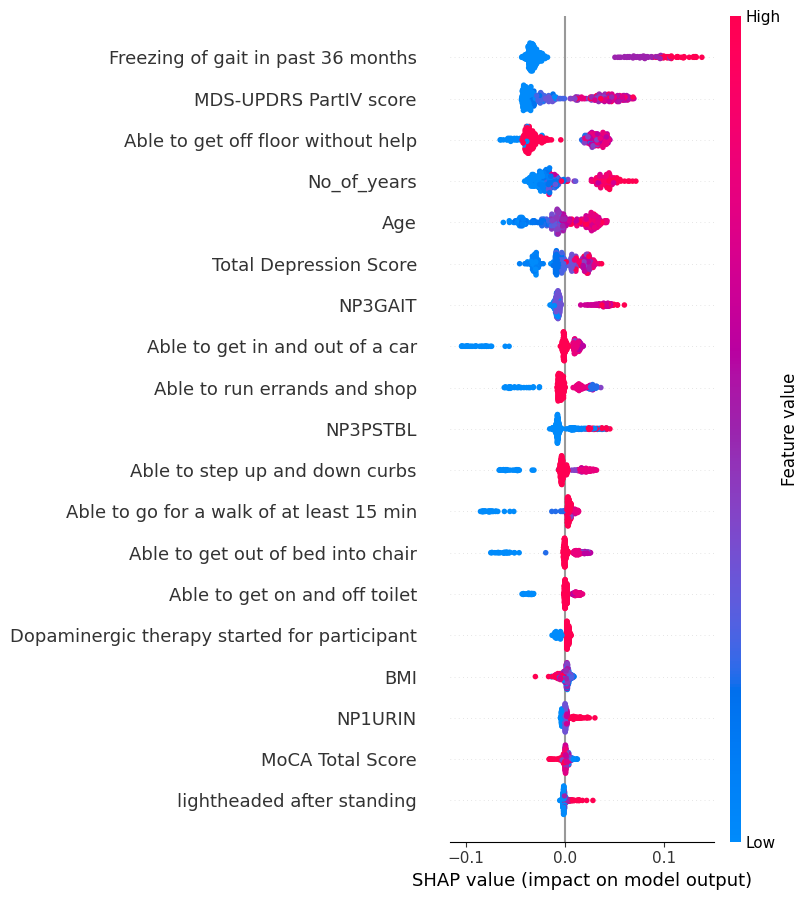

In [36]:
# Compute SHAP values
import shap
explainer = shap.Explainer(best_stage1, X_train)
shap_values = explainer(X_test)
# Select SHAP values for class 1 (any-fall)
shap_vals_stage1 = shap_values.values[:, :, 1]

# Beeswarm plot (all 19 features)
shap.summary_plot(
    shap_vals_stage1,
    X_test,
    plot_type="dot",     # beeswarm
    max_display=19
)

#Gaussian weight to able to features\
Value	Meaning	Gaussian Weight (σ=1.2)\
0	Fully able	0.18\
1	Mostly able	0.53\
2	Moderate difficulty	0.91\
3	Moderate difficulty	0.91\
4	Mostly unable	0.53\
5	Fully unable	0.18\

In [52]:
import numpy as np

def gaussian_weight(x, mu=2.5, sigma=1.2):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

able_cols = [
    'Able to get on and off toilet',
    'Able to step up and down curbs',
    'Able to get in and out of a car',
    'Able to get out of bed into chair',
    'Able to run errands and shop',
    'Able to get off floor without help',
    'Able to go for a walk of at least 15 min'
]

# Apply gaussian weight to each value and sum across features
data5['able_weighted_score'] = (
    data5[able_cols]
    .apply(lambda col: col.apply(lambda x: gaussian_weight(x) if pd.notna(x) else np.nan))
    .sum(axis=1)
)


In [ ]:
#Add No.of years/BMI

data['BMI-No.ofYears']= data['No_of_years']/data['BMI']

In [72]:
cols = ['No_of_years','Age',
       'Postural instability present at dx?','Rigidity present at diagnosis?',
       'Dopaminergic therapy started for participant', 'MoCA Total Score',
       'Freezing of gait in past 36 months',
       'lightheaded after standing', 'fainted',
        'Total Depression Score', 'able_weighted_score',
       'MDS-UPDRS PartIV score','BMI','NHY','NP3PSTBL','FEATPOSHYP',
       'NP1SLPD','NP1URIN','NP3GAIT'
]
# Compute age manually
# Convert "MM/YYYY" to a proper date (set day=1)
data5['BIRTHDT'] = pd.to_datetime(data5['BIRTHDT'], format='%m/%Y')
data5['Age'] = (today.year - data5['BIRTHDT'].dt.year) - \
              ((today.month < data5['BIRTHDT'].dt.month).astype(int))
X = data5[cols]
Y = data5['Falls not rel to freezing past 36 months']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42, stratify=Y)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Stage-1 Best Params: {'max_depth': 6, 'max_features': 0.3, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Stage-1 best params (LinearSVC): {'max_depth': 6, 'max_features': 0.3, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Stage-2 Best Params: {'clf__C': 1}

=== Two-Stage Classification Report (3-class) ===
              precision    recall  f1-score   support

         0.0     0.8000    0.8111    0.8055       217
         1.0     0.4872    0.3958    0.4368        96
         2.0     0.5094    0.7105    0.5934        38

    accuracy                         0.6866       351
   macro avg     0.5989    0.6391    0.6119       351
weighted avg     0.6830    0.6866    0.6817       351


=== Stage-1 Report (0 vs {1,2}) ===
              precision    recall  f1-sc

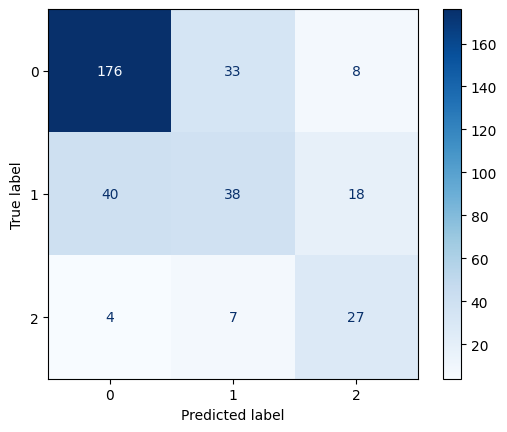

In [73]:
import numpy as np
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import make_scorer, confusion_matrix

rf_stage1 = RandomForestClassifier(class_weight={0: 1, 1: 2}, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5]
}

cv1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# gs_stage1 = GridSearchCV(
#     estimator=rf_stage1,
#     param_grid=param_grid,
#     cv=cv1,
#     scoring="f1",          # binary f1 for stage-1
#     n_jobs=-1,
#     verbose=1
# )
from sklearn.metrics import make_scorer, confusion_matrix

def cost_score(y_true, y_pred, fn_cost=5, fp_cost=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    cost = fn_cost*fn + fp_cost*fp
    return -cost  # GridSearchCV maximizes

stage1_cost_scorer = make_scorer(cost_score, greater_is_better=True, fn_cost=6, fp_cost=1)

gs_stage1 = GridSearchCV(
    rf_stage1,
    param_grid=param_grid,
    cv=cv1,
    scoring=stage1_cost_scorer,
    n_jobs=-1,
    verbose=1
)
y_train_s1 = (y_train != 0).astype(int)  # 0 -> 0, 1/2 -> 1
y_test_s1  = (y_test  != 0).astype(int)

# Fit stage-1
gs_stage1.fit(X_train, y_train_s1)
best_stage1 = gs_stage1.best_estimator_
print("Stage-1 Best Params:", gs_stage1.best_params_)
gs_stage1.fit(X_train, y_train_s1)
best_stage1 = gs_stage1.best_estimator_
print("Stage-1 best params (LinearSVC):", gs_stage1.best_params_)

svm_pipe1 = Pipeline([
    ("scaler", StandardScaler(with_mean=False) if hasattr(X_train, "sparse") else StandardScaler()),
    ("clf", LinearSVC(class_weight="balanced", random_state=42,dual=False))
])

param_grid_svm = {
    "clf__C": [0.01, 0.1, 1, 10]
}

gs_stage2 = GridSearchCV(
    svm_pipe1, param_grid_svm,
    cv=cv1,
    n_jobs=-1,
    verbose=1
)


# ---------------------------------------------------
# 3) Stage-2 training set: only samples with {1,2}
# ---------------------------------------------------
import pandas as pd

# Convert y to pandas Series with same index as X
y_train = pd.Series(y_train, index=X_train.index)
y_test  = pd.Series(y_test,  index=X_test.index)

# Now this works safely
mask_train_12 = y_train != 0
X_train_12 = X_train.loc[mask_train_12]
y_train_12 = y_train.loc[mask_train_12]
 

# Map {1,2} -> {0,1} for stage-2
y_train_s2 = (y_train_12 == 2).astype(int)  # 1 -> 0, 2 -> 1

# Fit stage-2
gs_stage2.fit(X_train_12, y_train_s2)
best_stage2 = gs_stage2.best_estimator_
print("Stage-2 Best Params:", gs_stage2.best_params_)

# ---------------------------------------
# 4) Two-stage inference on the test set
# ---------------------------------------
# Stage-1 prediction: 0 vs (1/2)
pred_s1 = best_stage1.predict(X_test)  # 0 or 1

# Initialize final preds as 0
y_pred_two_stage = np.zeros_like(y_test)

# For samples predicted as (1/2), run stage-2
idx_12 = np.where(pred_s1 == 1)[0]
if len(idx_12) > 0:
    pred_s2 = best_stage2.predict(X_test.iloc[idx_12])  # 0->class1, 1->class2
    y_pred_two_stage[idx_12] = np.where(pred_s2 == 0, 1, 2)

# -------------------------
# 5) Evaluation (3-class)
# -------------------------
print("\n=== Two-Stage Classification Report (3-class) ===")
print(classification_report(y_test, y_pred_two_stage, digits=4))

cm = confusion_matrix(y_test, y_pred_two_stage, labels=[0,1,2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2])
disp.plot(cmap="Blues")

# -------------------------
# 6) Optional: Stage-wise reports
# -------------------------
print("\n=== Stage-1 Report (0 vs {1,2}) ===")
print(classification_report(y_test_s1, pred_s1, digits=4))

# Evaluate stage-2 only where true label is in {1,2}
# 
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# mask of samples routed to stage-2 (stage-1 predicted {1,2})
mask_routed = (pred_s1 == 1)

# Subset X and y for only routed samples
X_routed = X_test.loc[mask_routed]
y_routed_true = y_test.loc[mask_routed]   # ground truth on routed samples

print("Routed samples count:", len(X_routed))
print("Routed true label distribution:\n", y_routed_true.value_counts().sort_index())

# Stage-2 predictions on routed samples
pred_s2_routed = best_stage2.predict(X_routed)  # 0/1 (meaning class1/class2)

# For stage-2 metrics, keep ONLY cases where ground truth is 1 or 2
mask_true_12 = y_routed_true.isin([1, 2])
y_true_12 = y_routed_true.loc[mask_true_12]

# Map y_true {1,2} -> {0,1} to match stage-2 outputs
y_true_s2 = (y_true_12 == 2).astype(int)

pred_s2_eval = pred_s2_routed[mask_true_12.to_numpy()]  # align with filtered y_true_12

print("\n=== Stage-2 Report (pipeline-routed subset, true in {1,2}) ===")
print(classification_report(y_true_s2, pred_s2_eval, digits=4))
print("Confusion matrix (rows=true [1,2]=>[0,1], cols=pred [0,1]):")
print(confusion_matrix(y_true_s2, pred_s2_eval))




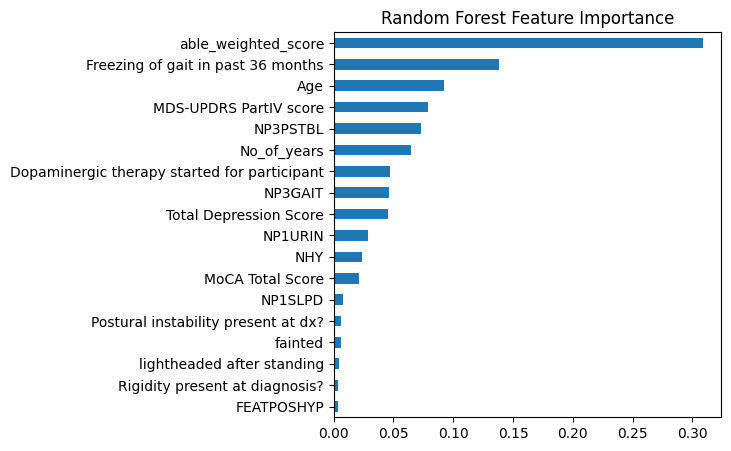

In [71]:
import matplotlib.pyplot as plt

rf_importances = pd.Series(best_stage1.feature_importances_, index=X_train.columns).sort_values(ascending=True)
rf_importances.plot(kind='barh', figsize=(5,5))
plt.title('Random Forest Feature Importance')
plt.show()


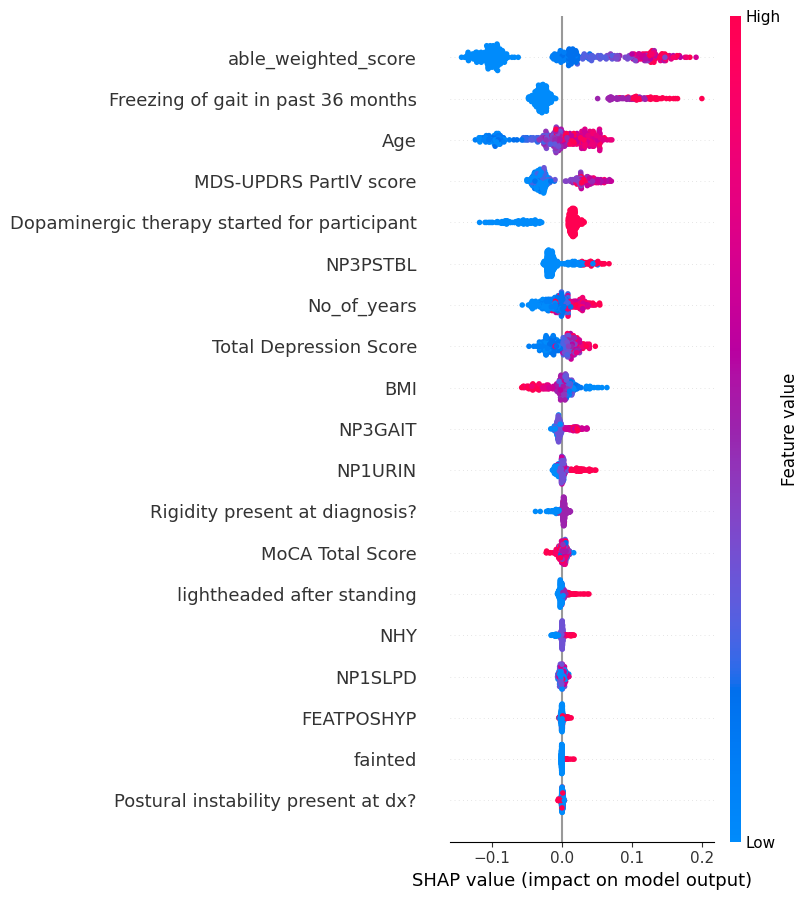

In [57]:
# Compute SHAP values
import shap
explainer = shap.Explainer(best_stage1, X_train)
shap_values = explainer(X_test)
# Select SHAP values for class 1 (any-fall)
shap_vals_stage1 = shap_values.values[:, :, 1]

# Beeswarm plot (all 19 features)
shap.summary_plot(
    shap_vals_stage1,
    X_test,
    plot_type="dot",     # beeswarm
    max_display=19
)

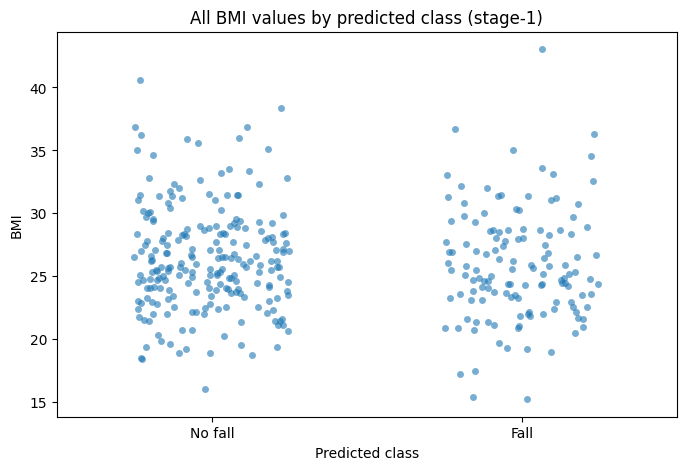

In [58]:

# Build DataFrame with BMI and predicted class
bmi_pred_df = pd.DataFrame({
    "BMI": X_test["BMI"].to_numpy(),
    "pred_class": pred_s1  # 0 = no fall, 1 = fall
})

# Optional: map to labels
bmi_pred_df["pred_label"] = bmi_pred_df["pred_class"].map({0: "No fall", 1: "Fall"})

plt.figure(figsize=(8, 5))
sns.stripplot(
    data=bmi_pred_df,
    x="pred_label",
    y="BMI",
    jitter=0.25,
    alpha=0.6
)
plt.title("All BMI values by predicted class (stage-1)")
plt.xlabel("Predicted class")
plt.ylabel("BMI")
plt.show()

In [ ]:
data[data['BMI']<18].shape

(21, 28)

Notes
- Analysis on BMI features(range of value for not fall and fall.
Strip plot: On the “Fall” side there are relatively more points in the lower BMI range; on the “No fall” side there are relatively more in the higher BMI range. So there is a tendency: lower BMI → more fall, higher BMI → more no fall.

In [64]:
data5.to_csv('data_with_additional_features.csv')

## Without combining able to features


In [49]:
able_cols = [
    'Able to get on and off toilet',
    'Able to step up and down curbs',
    'Able to get in and out of a car',
    'Able to get out of bed into chair',
    'Able to run errands and shop',
    'Able to get off floor without help',
    'Able to go for a walk of at least 15 min'
]

def gaussian_weight(x, mu=2.5, sigma=1.2):
    if pd.isna(x):
        return np.nan
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

data6 = data5.copy()

for col in able_cols:
    data6[col] = data6[col].apply(gaussian_weight)


In [50]:
cols = ['No_of_years','Age',
       'Postural instability present at dx?','Rigidity present at diagnosis?',
       'Dopaminergic therapy started for participant', 'MoCA Total Score',
       'Freezing of gait in past 36 months',
       'lightheaded after standing', 'fainted',
        'Total Depression Score', 'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min',
       'MDS-UPDRS PartIV score','BMI','NHY','NP3PSTBL','FEATPOSHYP',
       'NP1SLPD','NP1URIN','NP3GAIT'
]
# Compute age manually
# Convert "MM/YYYY" to a proper date (set day=1)
data6['BIRTHDT'] = pd.to_datetime(data6['BIRTHDT'], format='%m/%Y')
data6['Age'] = (today.year - data6['BIRTHDT'].dt.year) - \
              ((today.month < data6['BIRTHDT'].dt.month).astype(int))
X = data6[cols]
Y = data6['Falls not rel to freezing past 36 months']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42, stratify=Y)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Stage-1 Best Params: {'max_depth': 4, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Stage-1 best params (LinearSVC): {'max_depth': 4, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Stage-2 Best Params: {'clf__C': 0.01}

=== Two-Stage Classification Report (3-class) ===
              precision    recall  f1-score   support

         0.0     0.7885    0.7523    0.7700       218
         1.0     0.3889    0.3646    0.3763        96
         2.0     0.5000    0.7105    0.5870        38

    accuracy                         0.6420       352
   macro avg     0.5591    0.6091    0.5778       352
weighted avg     0.6483    0.6420    0.6428       352


=== Stage-1 Report (0 vs {1,2}) ===
              precision    recall

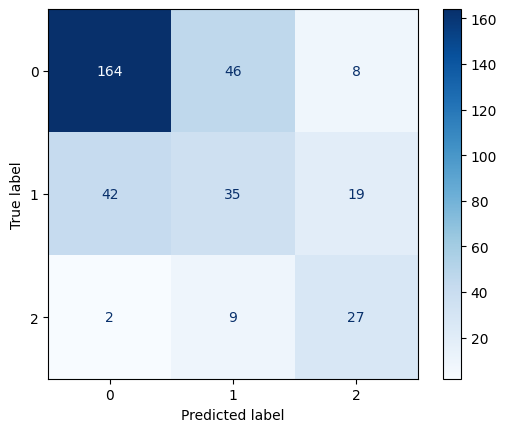

In [51]:
import numpy as np
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import make_scorer, confusion_matrix

rf_stage1 = RandomForestClassifier(class_weight={0: 1, 1: 2}, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5]
}

cv1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# gs_stage1 = GridSearchCV(
#     estimator=rf_stage1,
#     param_grid=param_grid,
#     cv=cv1,
#     scoring="f1",          # binary f1 for stage-1
#     n_jobs=-1,
#     verbose=1
# )
from sklearn.metrics import make_scorer, confusion_matrix

def cost_score(y_true, y_pred, fn_cost=5, fp_cost=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    cost = fn_cost*fn + fp_cost*fp
    return -cost  # GridSearchCV maximizes

stage1_cost_scorer = make_scorer(cost_score, greater_is_better=True, fn_cost=6, fp_cost=1)

gs_stage1 = GridSearchCV(
    rf_stage1,
    param_grid=param_grid,
    cv=cv1,
    scoring=stage1_cost_scorer,
    n_jobs=-1,
    verbose=1
)
y_train_s1 = (y_train != 0).astype(int)  # 0 -> 0, 1/2 -> 1
y_test_s1  = (y_test  != 0).astype(int)

# Fit stage-1
gs_stage1.fit(X_train, y_train_s1)
best_stage1 = gs_stage1.best_estimator_
print("Stage-1 Best Params:", gs_stage1.best_params_)
gs_stage1.fit(X_train, y_train_s1)
best_stage1 = gs_stage1.best_estimator_
print("Stage-1 best params (LinearSVC):", gs_stage1.best_params_)

svm_pipe1 = Pipeline([
    ("scaler", StandardScaler(with_mean=False) if hasattr(X_train, "sparse") else StandardScaler()),
    ("clf", LinearSVC(class_weight="balanced", random_state=42,dual=False))
])

param_grid_svm = {
    "clf__C": [0.01, 0.1, 1, 10]
}

gs_stage2 = GridSearchCV(
    svm_pipe1, param_grid_svm,
    cv=cv1,
    n_jobs=-1,
    verbose=1
)


# ---------------------------------------------------
# 3) Stage-2 training set: only samples with {1,2}
# ---------------------------------------------------
import pandas as pd

# Convert y to pandas Series with same index as X
y_train = pd.Series(y_train, index=X_train.index)
y_test  = pd.Series(y_test,  index=X_test.index)

# Now this works safely
mask_train_12 = y_train != 0
X_train_12 = X_train.loc[mask_train_12]
y_train_12 = y_train.loc[mask_train_12]
 

# Map {1,2} -> {0,1} for stage-2
y_train_s2 = (y_train_12 == 2).astype(int)  # 1 -> 0, 2 -> 1

# Fit stage-2
gs_stage2.fit(X_train_12, y_train_s2)
best_stage2 = gs_stage2.best_estimator_
print("Stage-2 Best Params:", gs_stage2.best_params_)

# ---------------------------------------
# 4) Two-stage inference on the test set
# ---------------------------------------
# Stage-1 prediction: 0 vs (1/2)
pred_s1 = best_stage1.predict(X_test)  # 0 or 1

# Initialize final preds as 0
y_pred_two_stage = np.zeros_like(y_test)

# For samples predicted as (1/2), run stage-2
idx_12 = np.where(pred_s1 == 1)[0]
if len(idx_12) > 0:
    pred_s2 = best_stage2.predict(X_test.iloc[idx_12])  # 0->class1, 1->class2
    y_pred_two_stage[idx_12] = np.where(pred_s2 == 0, 1, 2)

# -------------------------
# 5) Evaluation (3-class)
# -------------------------
print("\n=== Two-Stage Classification Report (3-class) ===")
print(classification_report(y_test, y_pred_two_stage, digits=4))

cm = confusion_matrix(y_test, y_pred_two_stage, labels=[0,1,2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2])
disp.plot(cmap="Blues")

# -------------------------
# 6) Optional: Stage-wise reports
# -------------------------
print("\n=== Stage-1 Report (0 vs {1,2}) ===")
print(classification_report(y_test_s1, pred_s1, digits=4))

# Evaluate stage-2 only where true label is in {1,2}
# 
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# mask of samples routed to stage-2 (stage-1 predicted {1,2})
mask_routed = (pred_s1 == 1)

# Subset X and y for only routed samples
X_routed = X_test.loc[mask_routed]
y_routed_true = y_test.loc[mask_routed]   # ground truth on routed samples

print("Routed samples count:", len(X_routed))
print("Routed true label distribution:\n", y_routed_true.value_counts().sort_index())

# Stage-2 predictions on routed samples
pred_s2_routed = best_stage2.predict(X_routed)  # 0/1 (meaning class1/class2)

# For stage-2 metrics, keep ONLY cases where ground truth is 1 or 2
mask_true_12 = y_routed_true.isin([1, 2])
y_true_12 = y_routed_true.loc[mask_true_12]

# Map y_true {1,2} -> {0,1} to match stage-2 outputs
y_true_s2 = (y_true_12 == 2).astype(int)

pred_s2_eval = pred_s2_routed[mask_true_12.to_numpy()]  # align with filtered y_true_12

print("\n=== Stage-2 Report (pipeline-routed subset, true in {1,2}) ===")
print(classification_report(y_true_s2, pred_s2_eval, digits=4))
print("Confusion matrix (rows=true [1,2]=>[0,1], cols=pred [0,1]):")
print(confusion_matrix(y_true_s2, pred_s2_eval))




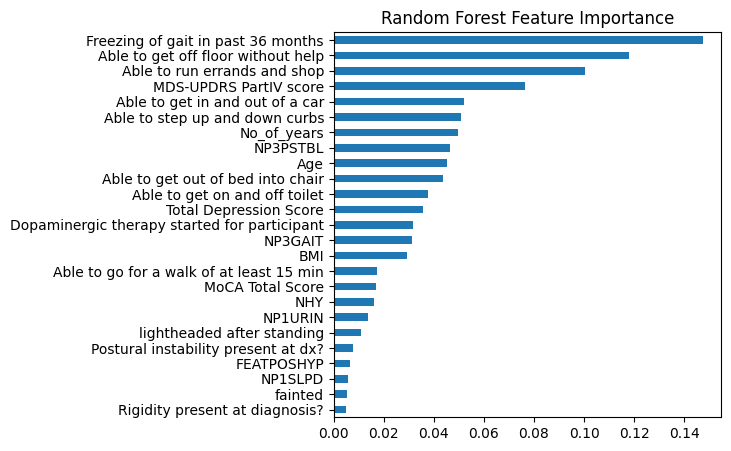

In [53]:
import matplotlib.pyplot as plt

rf_importances = pd.Series(best_stage1.feature_importances_, index=X_train.columns).sort_values(ascending=True)
rf_importances.plot(kind='barh', figsize=(5,5))
plt.title('Random Forest Feature Importance')
plt.show()


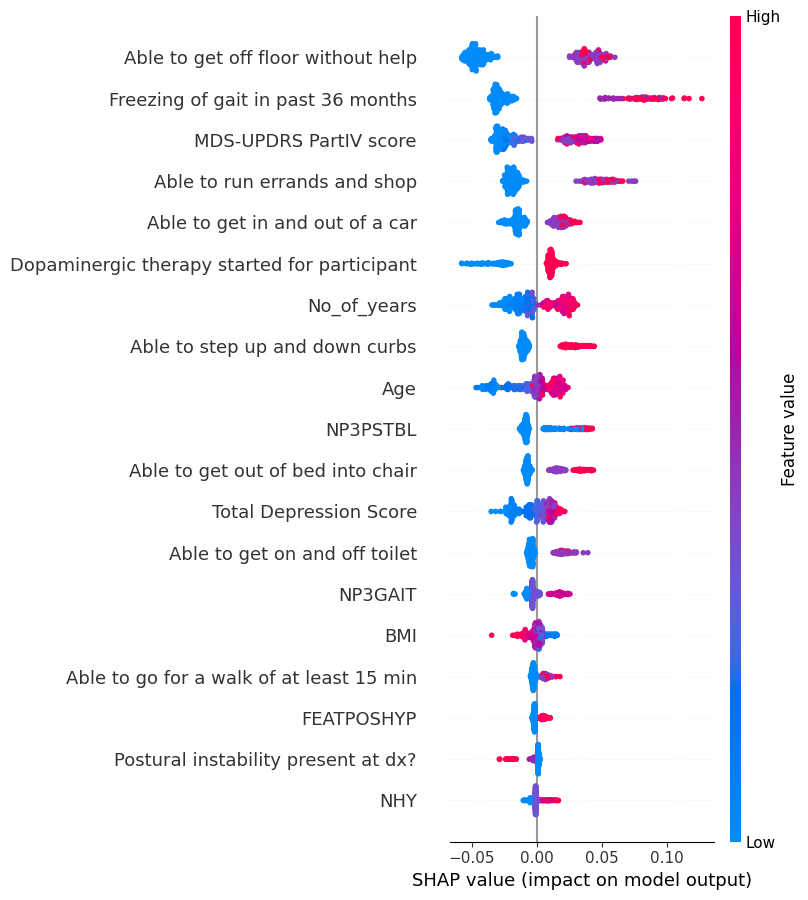

In [54]:
# Compute SHAP values
import shap
explainer = shap.Explainer(best_stage1, X_train)
shap_values = explainer(X_test)
# Select SHAP values for class 1 (any-fall)
shap_vals_stage1 = shap_values.values[:, :, 1]

# Beeswarm plot (all 19 features)
shap.summary_plot(
    shap_vals_stage1,
    X_test,
    plot_type="dot",     # beeswarm
    max_display=19
)

##Without new features - 

In [55]:
cols = ['No_of_years','Age',
       'Postural instability present at dx?','Rigidity present at diagnosis?',
       'Dopaminergic therapy started for participant', 'MoCA Total Score',
       'Freezing of gait in past 36 months',
       'lightheaded after standing', 'fainted',
        'Total Depression Score', 'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min',
       'MDS-UPDRS PartIV score','BMI'
]
# Compute age manually
# Convert "MM/YYYY" to a proper date (set day=1)
data6['BIRTHDT'] = pd.to_datetime(data6['BIRTHDT'], format='%m/%Y')
data6['Age'] = (today.year - data6['BIRTHDT'].dt.year) - \
              ((today.month < data6['BIRTHDT'].dt.month).astype(int))
X = data6[cols]
Y = data6['Falls not rel to freezing past 36 months']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42, stratify=Y)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Stage-1 Best Params: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Stage-1 best params (LinearSVC): {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Stage-2 Best Params: {'clf__C': 0.01}

=== Two-Stage Classification Report (3-class) ===
              precision    recall  f1-score   support

         0.0     0.7941    0.7431    0.7678       218
         1.0     0.3918    0.3958    0.3938        96
         2.0     0.4706    0.6316    0.5393        38

    accuracy                         0.6364       352
   macro avg     0.5522    0.5902    0.5670       352
weighted avg     0.6495    0.6364    0.6411       352


=== Stage-1 Report (0 vs {1,2}) ===
              precision    recall

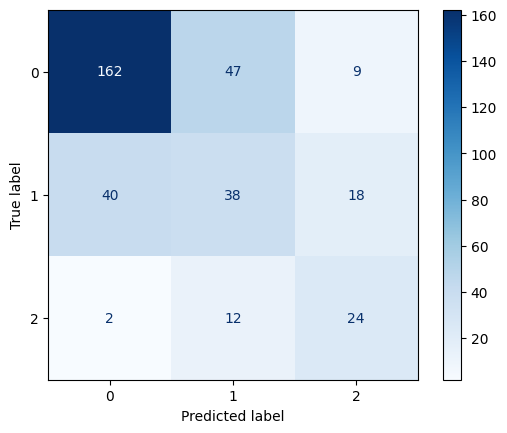

In [56]:
import numpy as np
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import make_scorer, confusion_matrix

rf_stage1 = RandomForestClassifier(class_weight={0: 1, 1: 2}, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5]
}

cv1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# gs_stage1 = GridSearchCV(
#     estimator=rf_stage1,
#     param_grid=param_grid,
#     cv=cv1,
#     scoring="f1",          # binary f1 for stage-1
#     n_jobs=-1,
#     verbose=1
# )
from sklearn.metrics import make_scorer, confusion_matrix

def cost_score(y_true, y_pred, fn_cost=5, fp_cost=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    cost = fn_cost*fn + fp_cost*fp
    return -cost  # GridSearchCV maximizes

stage1_cost_scorer = make_scorer(cost_score, greater_is_better=True, fn_cost=6, fp_cost=1)

gs_stage1 = GridSearchCV(
    rf_stage1,
    param_grid=param_grid,
    cv=cv1,
    scoring=stage1_cost_scorer,
    n_jobs=-1,
    verbose=1
)
y_train_s1 = (y_train != 0).astype(int)  # 0 -> 0, 1/2 -> 1
y_test_s1  = (y_test  != 0).astype(int)

# Fit stage-1
gs_stage1.fit(X_train, y_train_s1)
best_stage1 = gs_stage1.best_estimator_
print("Stage-1 Best Params:", gs_stage1.best_params_)
gs_stage1.fit(X_train, y_train_s1)
best_stage1 = gs_stage1.best_estimator_
print("Stage-1 best params (LinearSVC):", gs_stage1.best_params_)

svm_pipe1 = Pipeline([
    ("scaler", StandardScaler(with_mean=False) if hasattr(X_train, "sparse") else StandardScaler()),
    ("clf", LinearSVC(class_weight="balanced", random_state=42,dual=False))
])

param_grid_svm = {
    "clf__C": [0.01, 0.1, 1, 10]
}

gs_stage2 = GridSearchCV(
    svm_pipe1, param_grid_svm,
    cv=cv1,
    n_jobs=-1,
    verbose=1
)


# ---------------------------------------------------
# 3) Stage-2 training set: only samples with {1,2}
# ---------------------------------------------------
import pandas as pd

# Convert y to pandas Series with same index as X
y_train = pd.Series(y_train, index=X_train.index)
y_test  = pd.Series(y_test,  index=X_test.index)

# Now this works safely
mask_train_12 = y_train != 0
X_train_12 = X_train.loc[mask_train_12]
y_train_12 = y_train.loc[mask_train_12]
 

# Map {1,2} -> {0,1} for stage-2
y_train_s2 = (y_train_12 == 2).astype(int)  # 1 -> 0, 2 -> 1

# Fit stage-2
gs_stage2.fit(X_train_12, y_train_s2)
best_stage2 = gs_stage2.best_estimator_
print("Stage-2 Best Params:", gs_stage2.best_params_)

# ---------------------------------------
# 4) Two-stage inference on the test set
# ---------------------------------------
# Stage-1 prediction: 0 vs (1/2)
pred_s1 = best_stage1.predict(X_test)  # 0 or 1

# Initialize final preds as 0
y_pred_two_stage = np.zeros_like(y_test)

# For samples predicted as (1/2), run stage-2
idx_12 = np.where(pred_s1 == 1)[0]
if len(idx_12) > 0:
    pred_s2 = best_stage2.predict(X_test.iloc[idx_12])  # 0->class1, 1->class2
    y_pred_two_stage[idx_12] = np.where(pred_s2 == 0, 1, 2)

# -------------------------
# 5) Evaluation (3-class)
# -------------------------
print("\n=== Two-Stage Classification Report (3-class) ===")
print(classification_report(y_test, y_pred_two_stage, digits=4))

cm = confusion_matrix(y_test, y_pred_two_stage, labels=[0,1,2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2])
disp.plot(cmap="Blues")

# -------------------------
# 6) Optional: Stage-wise reports
# -------------------------
print("\n=== Stage-1 Report (0 vs {1,2}) ===")
print(classification_report(y_test_s1, pred_s1, digits=4))

# Evaluate stage-2 only where true label is in {1,2}
# 
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# mask of samples routed to stage-2 (stage-1 predicted {1,2})
mask_routed = (pred_s1 == 1)

# Subset X and y for only routed samples
X_routed = X_test.loc[mask_routed]
y_routed_true = y_test.loc[mask_routed]   # ground truth on routed samples

print("Routed samples count:", len(X_routed))
print("Routed true label distribution:\n", y_routed_true.value_counts().sort_index())

# Stage-2 predictions on routed samples
pred_s2_routed = best_stage2.predict(X_routed)  # 0/1 (meaning class1/class2)

# For stage-2 metrics, keep ONLY cases where ground truth is 1 or 2
mask_true_12 = y_routed_true.isin([1, 2])
y_true_12 = y_routed_true.loc[mask_true_12]

# Map y_true {1,2} -> {0,1} to match stage-2 outputs
y_true_s2 = (y_true_12 == 2).astype(int)

pred_s2_eval = pred_s2_routed[mask_true_12.to_numpy()]  # align with filtered y_true_12

print("\n=== Stage-2 Report (pipeline-routed subset, true in {1,2}) ===")
print(classification_report(y_true_s2, pred_s2_eval, digits=4))
print("Confusion matrix (rows=true [1,2]=>[0,1], cols=pred [0,1]):")
print(confusion_matrix(y_true_s2, pred_s2_eval))




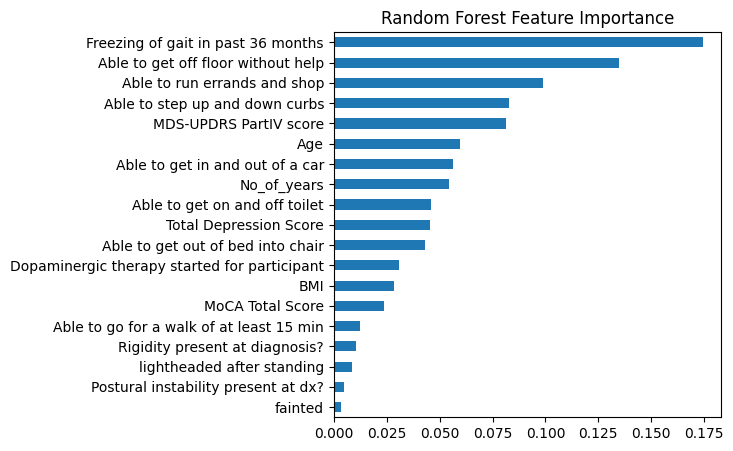

In [57]:
import matplotlib.pyplot as plt

rf_importances = pd.Series(best_stage1.feature_importances_, index=X_train.columns).sort_values(ascending=True)
rf_importances.plot(kind='barh', figsize=(5,5))
plt.title('Random Forest Feature Importance')
plt.show()


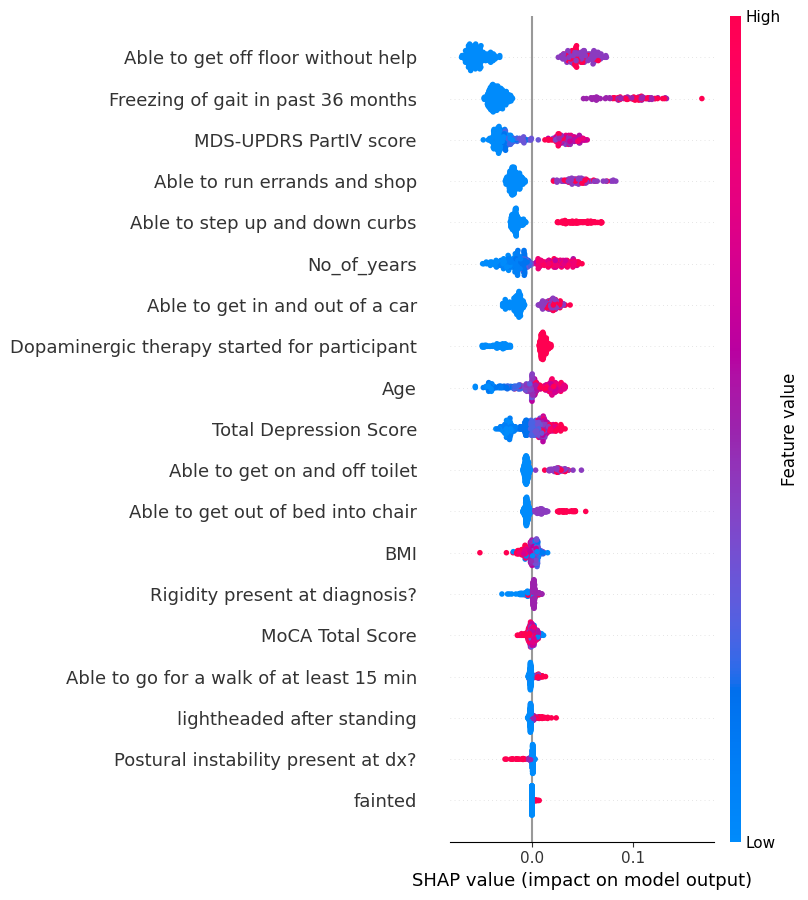

In [58]:
# Compute SHAP values
import shap
explainer = shap.Explainer(best_stage1, X_train)
shap_values = explainer(X_test)
# Select SHAP values for class 1 (any-fall)
shap_vals_stage1 = shap_values.values[:, :, 1]

# Beeswarm plot (all 19 features)
shap.summary_plot(
    shap_vals_stage1,
    X_test,
    plot_type="dot",     # beeswarm
    max_display=19
)

In [ ]:
# Build DataFrame with BMI and predicted class
bmi_pred_df = pd.DataFrame({
    "BMI": X_test["BMI"].to_numpy(),
    "pred_class": pred_s1  # 0 = no fall, 1 = fall
})

# Optional: map to labels
bmi_pred_df["pred_label"] = bmi_pred_df["pred_class"].map({0: "No fall", 1: "Fall"})

plt.figure(figsize=(8, 5))
sns.stripplot(
    data=bmi_pred_df,
    x="pred_label",
    y="BMI",
    jitter=0.25,
    alpha=0.6
)
# Add median lines for each group
for i, label in enumerate(["No fall", "Fall"]):
    med = bmi_pred_df.loc[bmi_pred_df["pred_label"] == label, "BMI"].median()
    plt.hlines(med, i - 0.4, i + 0.4, colors="black", linewidth=2, linestyle="--")
plt.title("All BMI values by predicted class (stage-1)")
plt.xlabel("Predicted class")
plt.ylabel("BMI")
plt.show()